This Try-it activity will walk through a clustering model for sample customer data. We will be splitting the customers into groups in order to get greater insight of our customer demographics and spending trends.  

Start by downloading [this](https://mo-pcco.s3.us-east-1.amazonaws.com/MO-PCDS/module4/activity-name-1_starter.zip) data. Once the dataset is downloaded for you locally, execute the code set below and upload the csv file to the Colab Notebook. 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plot
import seaborn as sns
import plotly.express as pxp
import plotly.graph_objs as gph
from sklearn import metrics
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
#from google.colab import files


#uploaded = files.upload()
data = pd.read_csv('4-1Data.csv')
data.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Drop the unused column.

In [4]:
data.drop('CustomerID', axis=1, inplace=True)

In [5]:
data.head()

,Gender,Age,AnnualIncome,SpendingScore
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


We can check the distribution of columns in data to see how data is distributed in various columns.

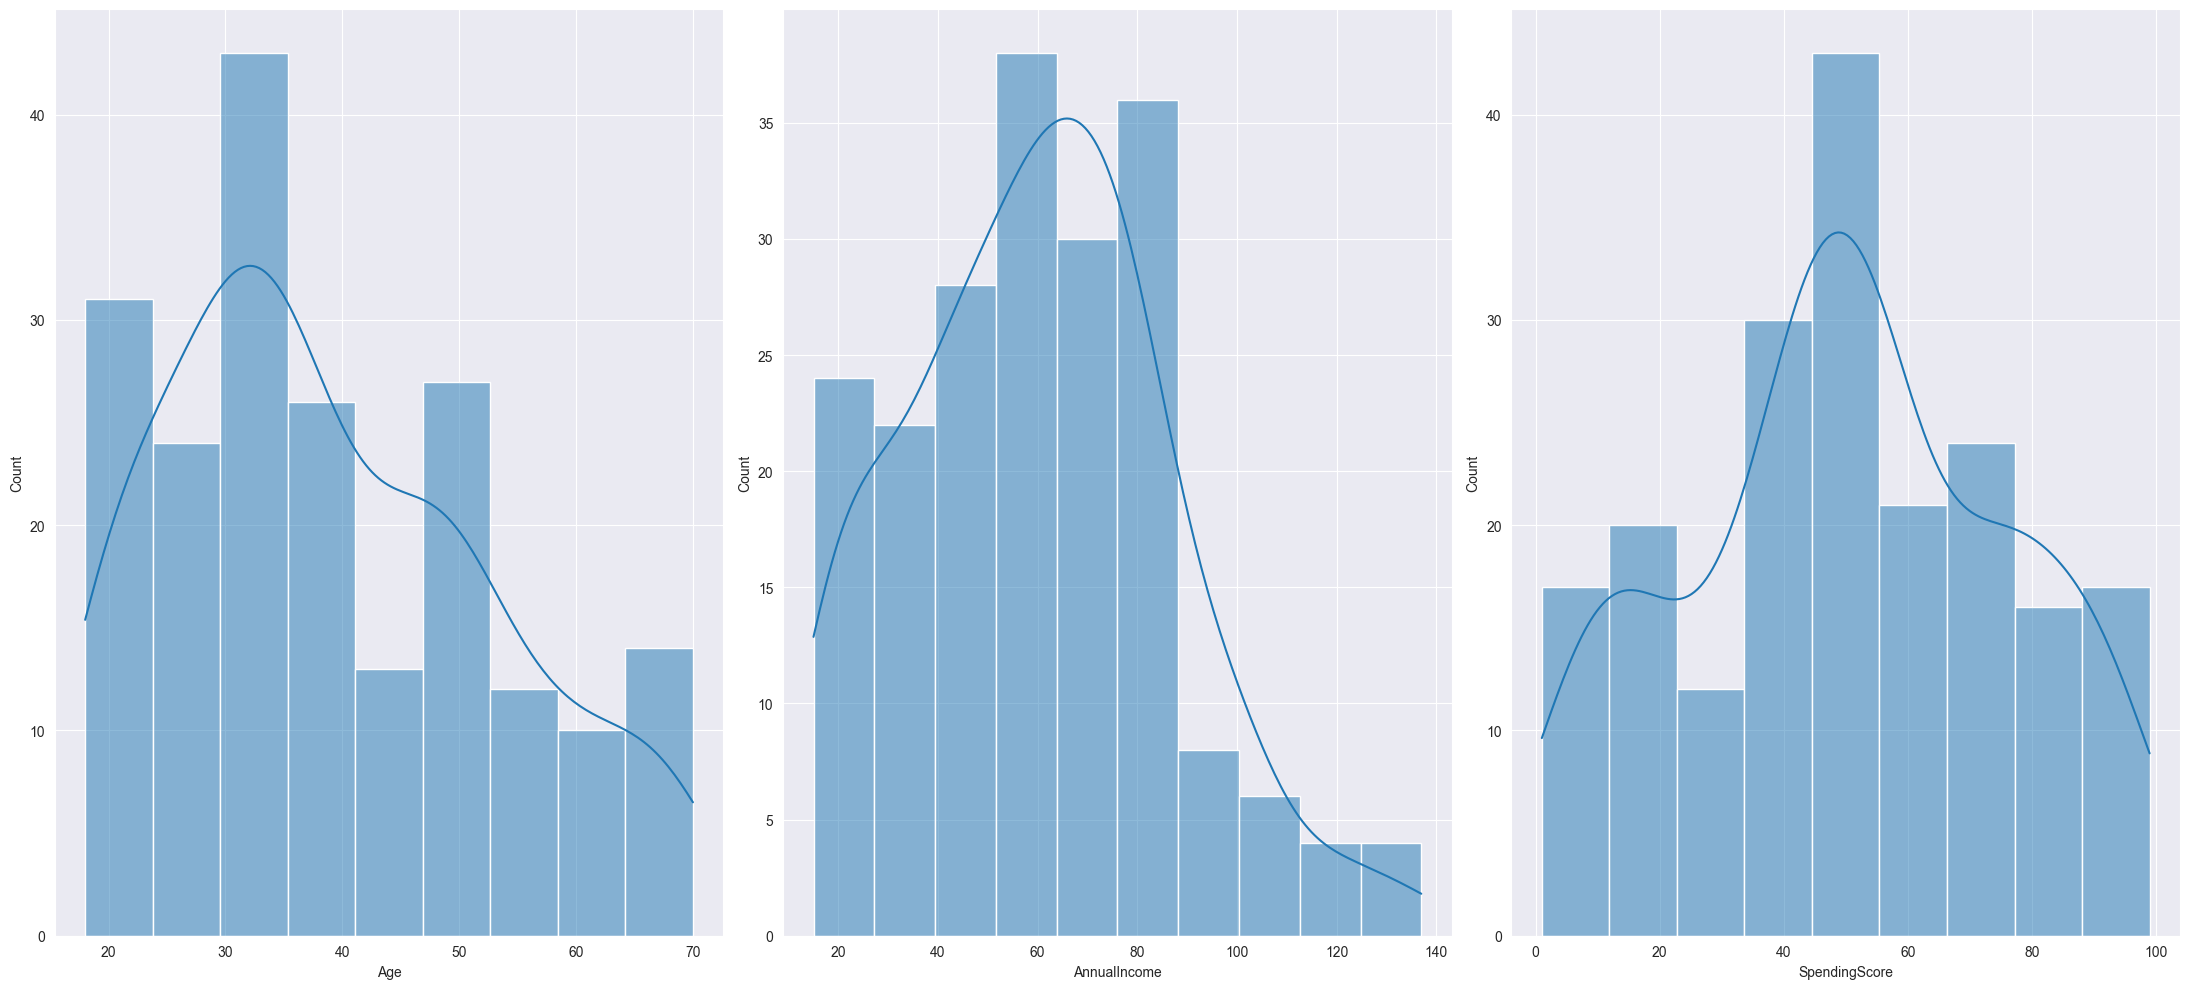

In [7]:
plot.figure(figsize = (22, 10))
plotnum = 1

for cols in ['Age', 'AnnualIncome', 'SpendingScore']:
    if plotnum <= 3:
        axs = plot.subplot(1, 3, plotnum)
        #sns.distplot(data[cols])
        sns.histplot(data[cols], kde=True)  # kde=True adds smooth curve
        
    plotnum += 1
    
plot.tight_layout()
plot.show()

Now let’s create a bar plot to check the distribution of customers in particular age groups. You can also apply the same to visualize the number of customers versus spending scores and the number of customers based on their annual income.

In [8]:
age_55above = data.Age[data.Age >= 55]
age_46_55 = data.Age[(data.Age >= 46) & (data.Age <= 55)]
age_36_45 = data.Age[(data.Age >= 36) & (data.Age <= 45)]
age_26_35 = data.Age[(data.Age >= 26) & (data.Age <= 35)]
age_18_25 = data.Age[(data.Age >= 18) & (data.Age <= 25)]

In [9]:
x_age_ax = ['18-25', '26-35', '36-45', '46-55', '55+']
y_age_ax = [len(age_18_25.values), len(age_26_35.values), len(age_36_45.values), len(age_46_55.values),
     len(age_55above.values)]

pxp.bar(data_frame = data, x = x_age_ax, y = y_age_ax, color = x_age_ax,
       title = 'Count of customers per age group')

One of the most critical aspects of clustering is selecting the correct value of K. Randomly selecting K might not be a favorable choice. We’ll be using the elbow method and silhouette score to choose the value of K.

In our case, from the below graph, it looks like the optimal value of K found from the elbow method is 4. We want to maximize the number of clusters and limit cases where each data point becomes its cluster centroid.

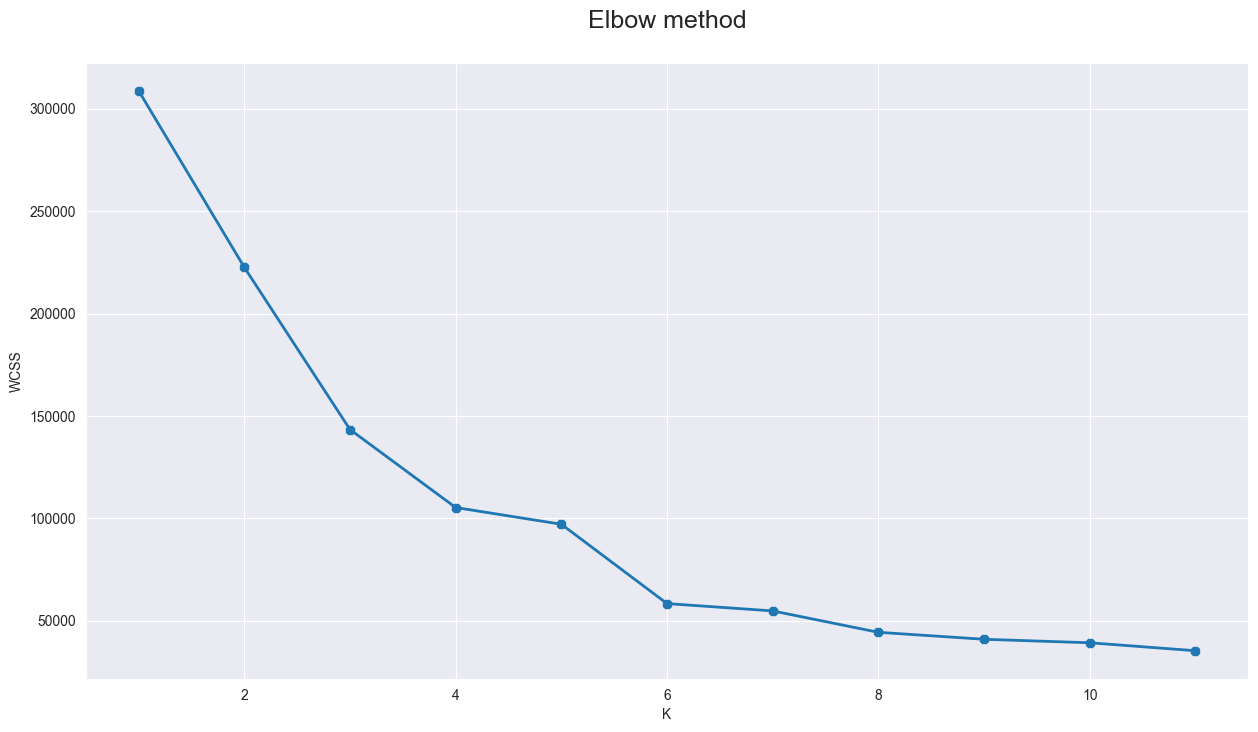

In [13]:
x_input = data.loc[:, ['Age', 'SpendingScore','AnnualIncome']].values


wcss = []
for k in range(1, 12):
    k_means = KMeans(n_clusters=k, init='k-means++')
    k_means.fit(x_input)
    wcss.append(k_means.inertia_)
    
plot.figure(figsize=(15,8))

plot.plot(range(1, 12), wcss, linewidth=2, marker='8')
plot.title('Elbow method\n', fontsize=18)
plot.xlabel('K')
plot.ylabel('WCSS')
plot.show()

In [16]:
k_means=KMeans(n_clusters=8)
labels=k_means.fit_predict(x_input)
print(k_means.cluster_centers_)

[[ 60.48275862  49.62068966  50.48275862]
 [ 24.86666667  51.96666667  53.33333333]
 [ 41.          22.         109.7       ]
 [ 44.14285714  19.52380952  25.14285714]
 [ 32.69230769  82.12820513  86.53846154]
 [ 40.2173913   13.39130435  79.73913043]
 [ 44.48148148  45.18518519  62.48148148]
 [ 25.33333333  80.04761905  25.0952381 ]]


Now let’s plot a graph to check how the clusters are formed from the data.

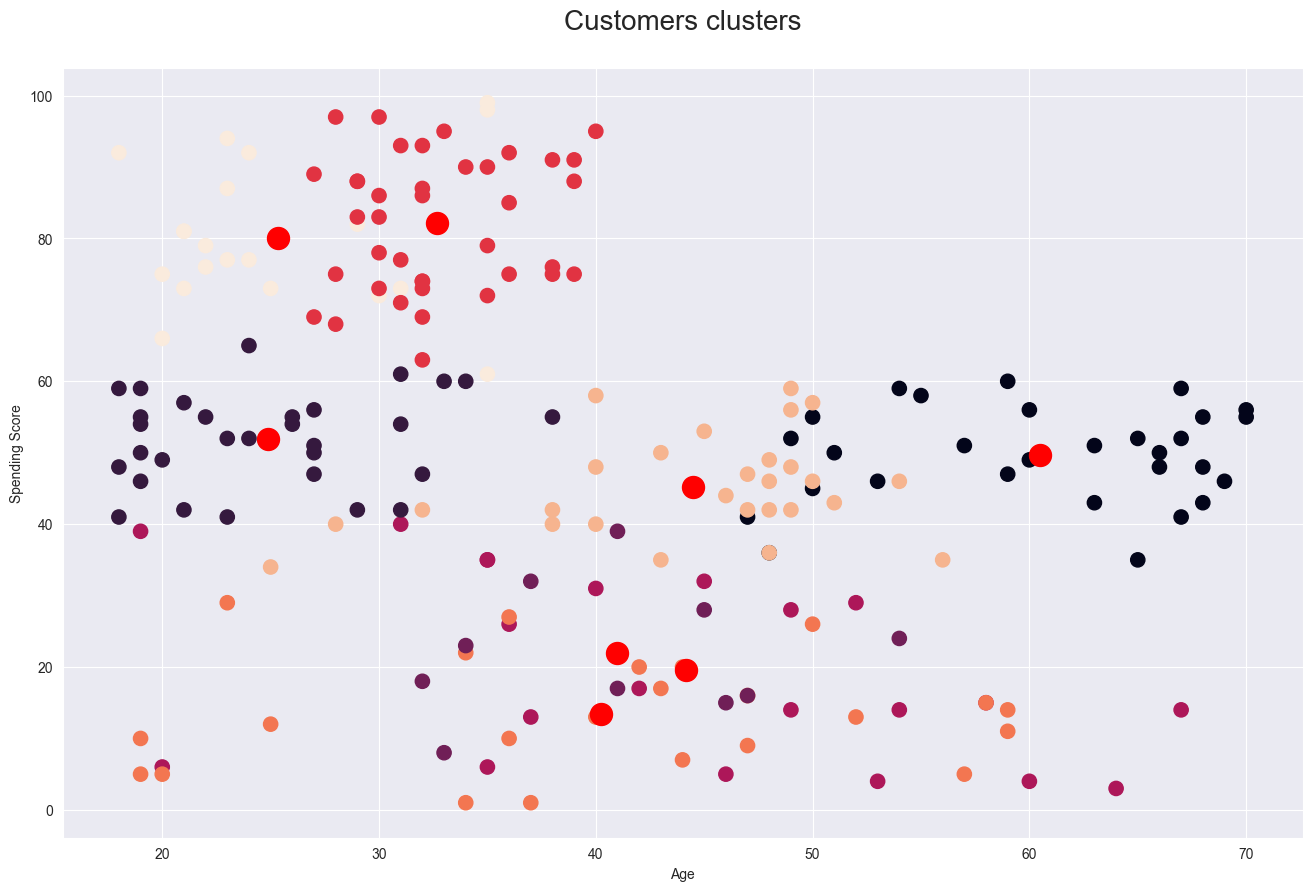

In [17]:
plot.figure(figsize = (16, 10))
plot.scatter(x_input[:, 0], x_input[:, 1], c =
k_means.labels_, s = 105)
plot.scatter(k_means.cluster_centers_[:, 0],k_means.cluster_centers_[:, 1], color = 'red', s = 250)
plot.title('Customers clusters\n', fontsize = 20)
plot.xlabel('Age')
plot.ylabel('Spending Score')
plot.show()

In [ ]:
'''
⸻

📊 Spending Trends Observed in the Clusters

From the clustering results, distinct spending patterns emerged across the groups. One cluster demonstrated consistently higher overall spending levels, suggesting this group may represent higher-income or more frequent shoppers. This cluster likely reflects customers who engage more actively with products or services and may respond well to premium offerings or loyalty programs.

In contrast, another cluster showed lower or more moderate spending behavior. These individuals may be more price-sensitive or occasional buyers. The separation of clusters highlights behavioral segmentation rather than just demographic grouping, which can provide more actionable business insight.

Overall, the clustering revealed meaningful differences in spending intensity and purchasing behavior, suggesting targeted marketing strategies could be developed for each segment.

⸻

        Alternative Variables Beyond Age

While age is often used for segmentation, there are several other variables that could have been useful in this scenario:
	•	Income level – Often directly linked to purchasing power.
	•	Purchase frequency – Captures engagement level more accurately than age.
	•	Total annual spending – Indicates customer lifetime value potential.
	•	Customer tenure (length of relationship) – Helps identify loyalty segments.
	•	Product category preferences – Reveals behavioral clusters rather than demographic ones.

In many cases, behavioral variables (e.g., spending frequency or transaction size) can be more predictive of customer patterns than demographic variables like age.

⸻

🎯 Future Application

In future analyses, I would combine demographic and behavioral variables to form richer clusters. Including spending frequency, recency of purchase, or transaction volume could improve cluster differentiation and create more actionable insights for pricing strategies, promotions, and customer retention initiatives.

⸻

If you’d like, I can tailor this specifically to:
	•	Retail
	•	Banking/credit
	•	Technology platforms
	•	Insurance
	•	E-commerce'''

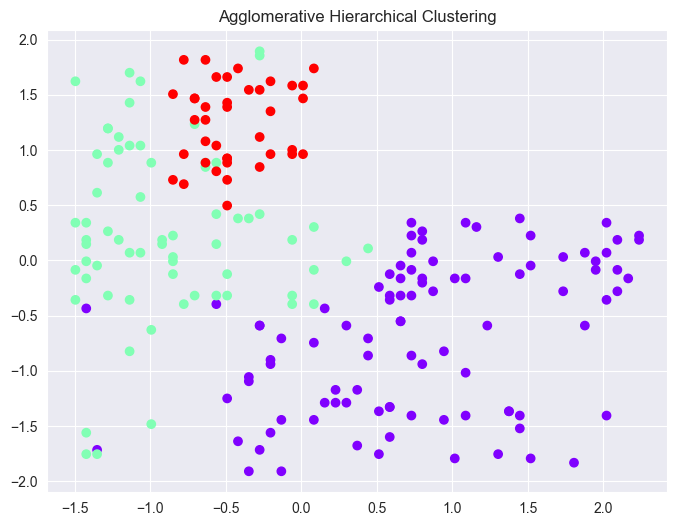

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

# Generate sample data
#X, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.5, random_state=42)

# Scale the data (IMPORTANT for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_input)

# Apply Agglomerative Clustering
ahc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = ahc.fit_predict(X_scaled)

# Plot results
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='rainbow')
plt.title("Agglomerative Hierarchical Clustering")
plt.show()

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/

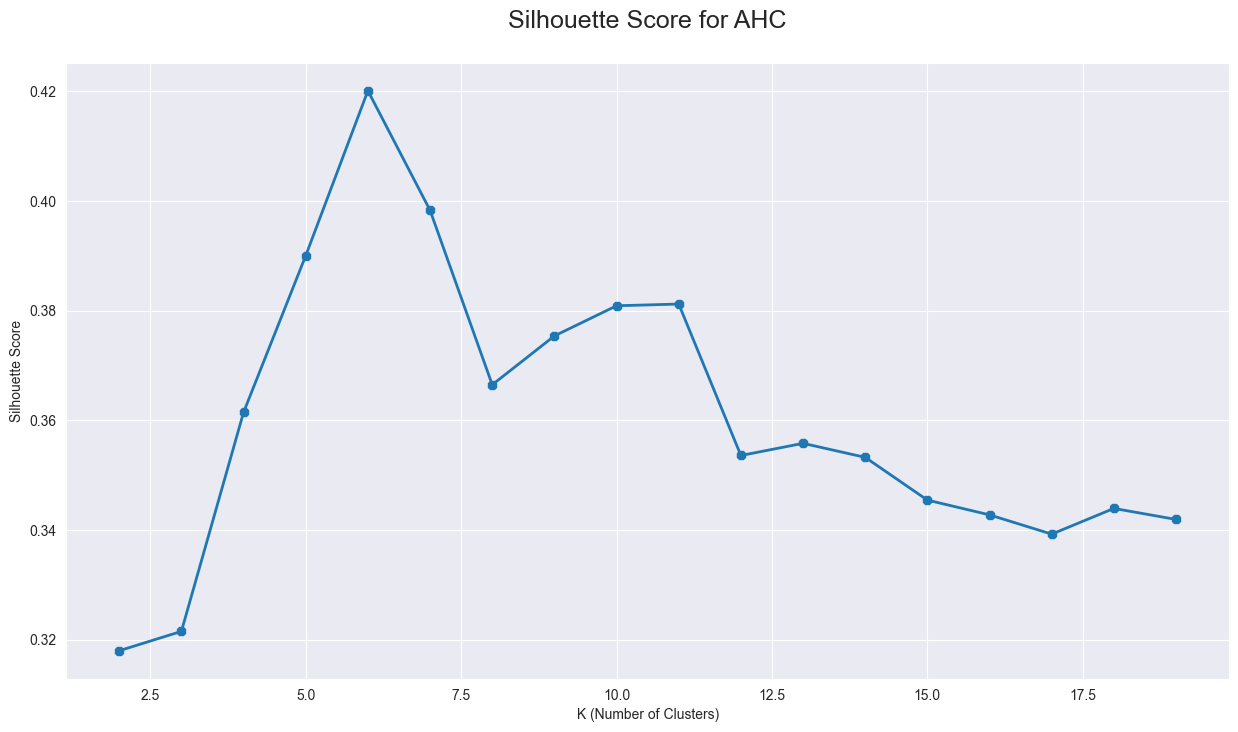

In [28]:
scores = []
K = range(2, 20)  # Silhouette needs at least 2 clusters

for k in K:
    ahc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = ahc.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plot.figure(figsize=(15, 8))
plot.plot(K, scores, linewidth=2, marker='8')
plot.title('Silhouette Score for AHC\n', fontsize=18)
plot.xlabel('K (Number of Clusters)')
plot.ylabel('Silhouette Score')
plot.show()


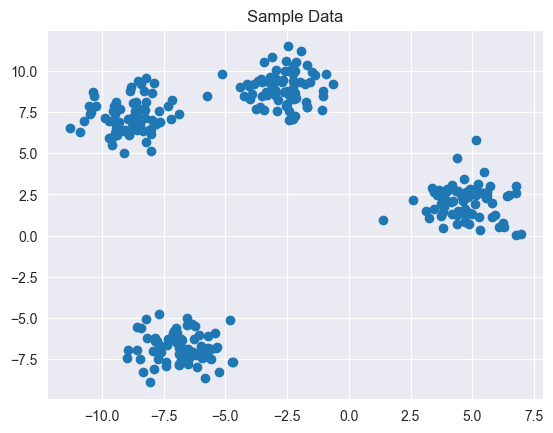

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Create synthetic dataset
X, y = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

plt.scatter(X[:, 0], X[:, 1])
plt.title("Sample Data")
plt.show()



/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/

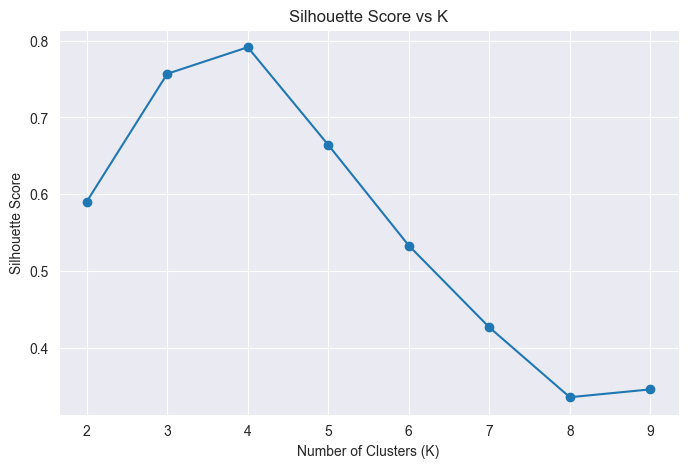

In [31]:
silhouette_scores = []

K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

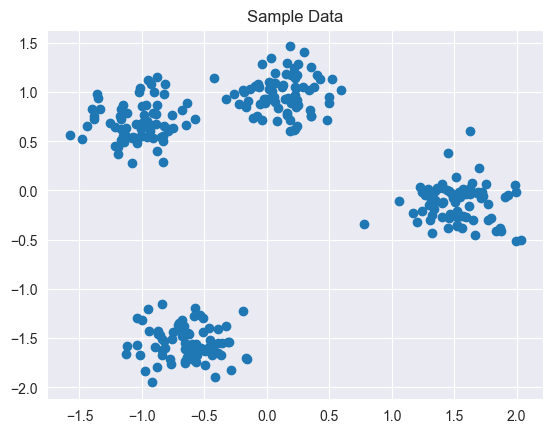

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples

# Generate synthetic data
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=42)

# Scale data (IMPORTANT for distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.title("Sample Data")
plt.show()

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/ajaikolarikal/PyCharmMiscProject/.venv/lib/python3.9/

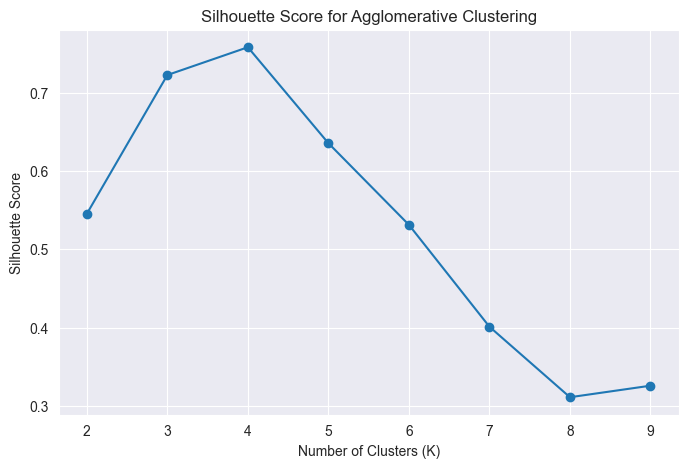

In [33]:
sil_scores = []

for k in range(2, 10):
    ahc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = ahc.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2, 10), sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Agglomerative Clustering")
plt.show()